In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.io import fits
from astropy.nddata import Cutout2D
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows

# pip install matplotlib-scalebar

In [2]:
#Okay let's get some practice opening and working with astronomy images!
#Almost all files from a telescope will come in the form of a FITS file
#We're going to practice with an image made by stacking 1207 individual 
#images from ASAS-SN. The galaxy in this image is NGC253

#First, we need to load the image. To do this, copy the filepath to the image and set
#filename equal to it. The file is available on the OneDrive and is called
#NGC253_ASASSN_Field.fits'

filename='NGC253_ASASSN_Field.fits'

#Once the filename is assigned to the variable, we can use astropy.fits to load it!

ASASSNhdulist=fits.open(filename)
ASASSNhdu=ASASSNhdulist[0]

In [3]:
#At this point, ASASSNhdu is made up of two components: the actual data, and the header. 
#Let's print both components and see what they look like!

print('The data looks like')
print(ASASSNhdu.data)

print('The header looks like')
print(ASASSNhdu.header)


The data looks like
[[0.00835606 0.00845507 0.00854971 ... 0.00653425 0.00656921 0.00655982]
 [0.00841744 0.00854971 0.00866293 ... 0.00651626 0.00654434 0.00653425]
 [0.00857951 0.00870587 0.00884793 ... 0.00654434 0.00653425 0.00655517]
 ...
 [0.00849771 0.00883078 0.00905103 ... 0.00987728 0.00934654 0.00908731]
 [0.00837946 0.00863187 0.00893847 ... 0.00943823 0.0091348  0.0089463 ]
 [0.0083226  0.00846627 0.00882058 ... 0.00923531 0.00905103 0.00877621]]
The header looks like
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 2048                                                  NAXIS2  =                 2048                                                  ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-12-03T11:46:53' / 

In [4]:
#The data is a 2D array with a size of 2048x2048. This is the size of ASAS-SN's detectors!
#Each value in the array is a measure of how much flux is received from the sky at that point

#The header is kind of like a dictionary story a bunch of different important values!
#We can access different values in the following way!
NImages=ASASSNhdu.header['N_IMG']
print('The number of images combined here is ',NImages)

The number of images combined here is  1207


In [5]:
#Now, use this cell to figure out the total exposure time used to create this image




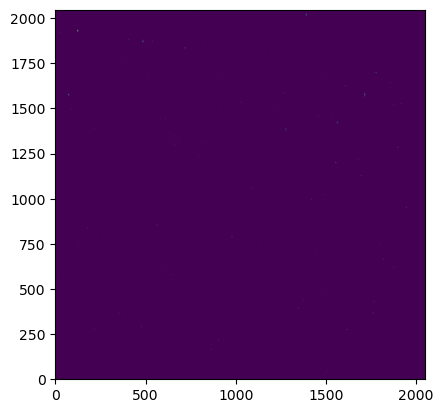

In [6]:
#Okay, we've messed with the header. Now let's mess with the data! Let's start by just displaying it!
#The easiest way to display 2D data like this is using plt.imshow()

plt.imshow(ASASSNhdu.data, origin='lower')
plt.show()


In [7]:
#Okay that was underwhelming. It basically just looks like a purple square
#However, one positive sign is that it looks to be a square that is 2048x2048
#so we did something right. 

#Here are a few things we can do to make this more presentable
# 1.) Choose a colorscheme that is more widely used in astronomy
# 2.) Make sure our origin is in the right place
# 3.) Adjust the range of pixel values we are displaying, and the way we scale them (This is like messing with scale parameters
#in ds9)



In [8]:
#The first one is easy! Python has a bunch of premade colormaps that we can choose from
#For looking at extended objects, Greys is a popular one
cmap=plt.cm.Greys_r
#Now we have the color scheme we want saved to the variable cmap

In [9]:
#The second one isn't too bad either! We want the origin of our image to be
#at the bottom. To do this, we just have to let it know!
origin_pos='lower'
#If instead we said origin_pos='upper', it would display upside down!

In [10]:
#Point 3 is much trickier. Finding a decent range is hard, but not impossible
#we want the lowest pixel value we display to be roughly equivalent to the background.
#Most pixels are background pixels, so the median pixel value should be roughly equal to the bg
minim_med=np.nanmedian(ASASSNhdu.data)

#Another (and slightly more versatile) way to find this is using percentiles!
minim_per=np.nanpercentile(ASASSNhdu.data, 50)

#If we print both of these, they should be the same!
print(minim_med)
print(minim_per)

156.68872
156.68872


In [11]:
#Okay, so we have a decent minimum pixel
minim=np.nanpercentile(ASASSNhdu.data, 50)
#Now we need a maximum. This is harder to find. I usually start with somewhere in the 90-95th percentile
maxim=np.nanpercentile(ASASSNhdu.data, 90)

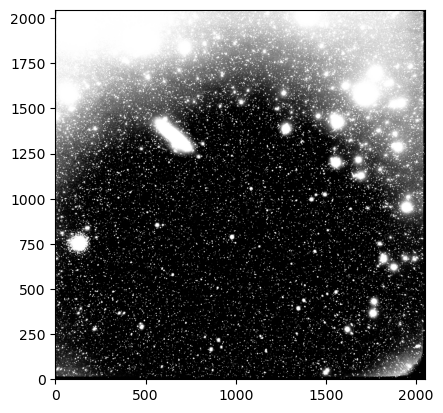

In [12]:
#Nice! We have all the components, now let's try displaying again!
plt.imshow(ASASSNhdu.data, origin=origin_pos, cmap=cmap, vmin=minim, vmax=maxim)
plt.show()

In [13]:
#Nice! Now we can see dots and blobs! Those dots and blobs are stars and galaxies! Now, we want to
#Make a zoomed in cutout on the big galaxy! To do this, we need a position and a size!
#Make a rough estimate of where the galaxy is centered
x=650
y=1350
position=(x,y)

#And a rough estimate of a good size for the galaxy
pixels=200
size=(pixels,pixels)

In [14]:
# Now, we can use the Cutout2D function to make the zoom in!
cutout=Cutout2D(ASASSNhdu.data, position, size)

In [15]:
#Let's use the same tactic as before to establish a decent pixel value range
minim=np.nanpercentile(cutout.data, 50)
maxim=np.nanpercentile(cutout.data, 99)

In [16]:
#Now I want you to try to display the cutout the same way we displayed the full image above!


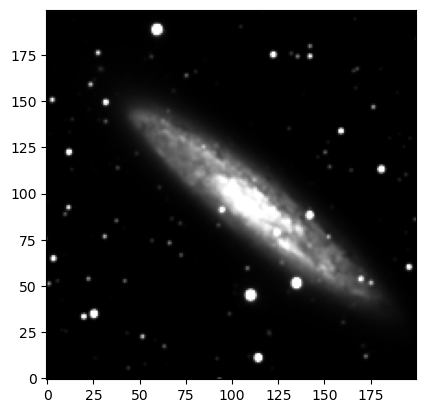

In [17]:
plt.imshow(cutout.data, origin=origin_pos, cmap=cmap, vmin=minim, vmax=maxim)
plt.show()

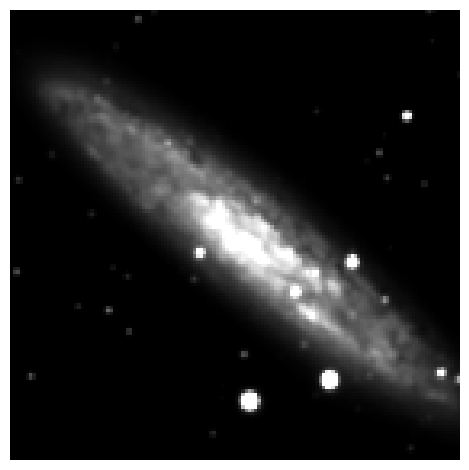

In [18]:
#Okay hopefully after some trial and error, you have an image that looks similar to the one below
Evan_position=(656, 1347)
Evan_size=(140,140)
Evan_cutout=Cutout2D(ASASSNhdu.data, Evan_position, Evan_size)

Evan_minim=np.percentile(Evan_cutout.data, 60)
Evan_maxim=np.percentile(Evan_cutout.data, 99)


plt.imshow(Evan_cutout.data, origin='lower', cmap=cmap, vmin=Evan_minim, vmax=Evan_maxim)
plt.axis('off')
plt.tight_layout()

plt.show()

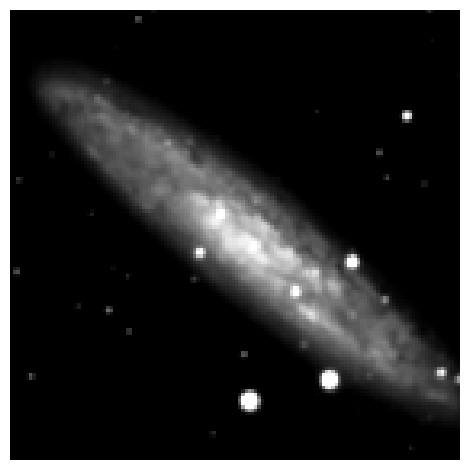

In [19]:
#There is one more trick we can use to make this look better, and that is choosing a different way to
#scale. By default, plt.imshow() uses linear scaling, but for showing something that covers a large range 
#in flux, like a galaxy, it can be better to use log scaling, like below!
Evan_minim=np.percentile(Evan_cutout.data, 70)
Evan_maxim=np.percentile(Evan_cutout.data, 99.7)


plt.imshow(Evan_cutout.data, origin='lower', cmap=cmap, vmin=Evan_minim, vmax=Evan_maxim, norm='log')
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Okay the last thing we'll do is add some important markers so that people looking at this
#can get some useful information out of this. We'll add a scalebar, so they know how big this
#galaxy is, and a compass so they know the orientation

In [20]:
#To add the scalebar, we will use the ScaleBar object. 
#ScaleBar(dx=, dimension=, units=, location=, frameon=, color=, pad=)
#The idea of the scale bar is for us to show how big a certain angle appears on this image
#so the dimension and units keywords will be set equal to 'angle' and 'deg' respectively
#dx represents how many degrees are in each pixel
#ASAS-SN's pixel scale is 7.8 arcseconds per pixel

#Convert this value to degrees!
PixScaleArcSeconds=7.8


In [ ]:
#The last 4 keywords (location, frameon, color, and pad) are just aesthetic choices

#location is where you want the scale bar to be: 'upper right', 'lower left' etc

#frameon is whether you want a box around the scalebar or not: True or False
#Color is the color: 'blue' 'red' etc.
#pad is how far you want it from the corner you choose: 1, 0.5, etc.
#Alright set things equal to what you want!
scale=ScaleBar(dx=, dimension=, units=, location=, frameon=, color=, pad=)

In [ ]:
#And now let's add it to the image!

#Fill in the imshow command
plt.imshow()

#This is how we add the scale bar
plt.gca().add_artist(scale)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#The last thing we'll add is the compass. This one is slightly trickier
compass = AnchoredDirectionArrows(plt.gca().transAxes, 'E', 'N', loc="lower right", color="red", 
                                  aspect_ratio=-1, back_length=0., length=-0.11, sep_y=0.03, 
                                  sep_x=-0.03)
#These are the values I use
#The tricky part is that when looking at the sky instead of the ground, E and W are flipped
#So to account for this, we have to make the aspect ratio and the length negative
#Pretty much everything else is aesthetic choice

In [ ]:
#Okay use this cell to display your final image with the scalebar and compass added

In [ ]:
#The cell below is what my final product looks like. Please don't cheat and look at it lol

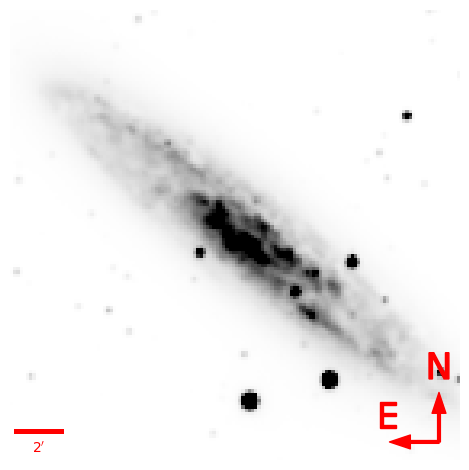

In [79]:
position=(656, 1347)
size=(140,140)
ASASSNcutout1=Cutout2D(ASASSNhdu.data, position, size)

minim1=np.percentile(ASASSNcutout1.data, 40)
maxim1=np.percentile(ASASSNcutout1.data, 99)

cmap=plt.cm.Greys
cmap.set_bad('grey')

compass = AnchoredDirectionArrows(plt.gca().transAxes, 'E', 'N', loc="lower right", color="red", aspect_ratio=-1, back_length=0., 
		length=-0.11, sep_y=0.03, sep_x=-0.03)

plt.imshow(ASASSNcutout1.data, origin='lower', cmap=cmap, vmin=minim1, vmax=maxim1)
scalebar1 = ScaleBar(dx=0.0021667, dimension='angle', units="deg", location="lower left", frameon=False, color='red', pad=0.2)
plt.gca().add_artist(compass)
plt.gca().add_artist(scalebar1)
plt.axis('off')
plt.tight_layout()

plt.show()